# Person Re-Identification — Improved Siamese Network

**Key improvements over baseline (Rank-1: 54.42%):**
1. **Data Augmentation**: Random Flip, Crop, Color Jitter, Random Erasing
2. **BN Neck**: Separates triplet & classification objectives
3. **Label Smoothing**: Cross-entropy with epsilon=0.1
4. **LR Schedule**: Warmup (10 epochs) + Cosine Annealing
5. **Loss Weighting**: Triplet + 0.5 × CE
6. **Larger Embedding**: 128 → 256 dimensions
7. **Full Evaluation**: Rank-1/5/10 + mAP


## 1. Setup and Imports

In [1]:
!pip install kagglehub -q

import os, random, math
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision.models as models
import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader
from collections import defaultdict
from PIL import Image
import kagglehub
import numpy as np
from scipy.spatial.distance import cdist
import matplotlib.pyplot as plt
import matplotlib.patches as patches

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')
print(f'PyTorch: {torch.__version__}')

Device: cuda
PyTorch: 2.10.0+cu128


## 2. Configuration, Drive Mount & Dataset Download

In [2]:
from google.colab import drive
drive.mount('/content/drive')

# ==================== Hyperparameters ====================
EMBEDDING_DIM   = 256
BATCH_SIZE      = 32
NUM_EPOCHS      = 80
BASE_LR         = 3.5e-4
WARMUP_EPOCHS   = 10
TRIPLET_MARGIN  = 0.3
CE_WEIGHT       = 0.5        # weight for CE loss in combined loss
LABEL_SMOOTH    = 0.1
RE_PROB         = 0.5        # random erasing probability
PATIENCE        = 12         # early stopping patience

# ==================== Checkpoint ====================
CKPT_DIR  = '/content/drive/MyDrive/ReID_Checkpoints'
os.makedirs(CKPT_DIR, exist_ok=True)
CKPT_PATH = os.path.join(CKPT_DIR, 'reid_improved_v2.pth')

# ==================== Download Market-1501 ====================
dataset_path = kagglehub.dataset_download('pengcw1/market-1501')
print('Dataset path:', dataset_path)

base_dir    = os.path.join(dataset_path, 'Market-1501-v15.09.15')
train_dir   = os.path.join(base_dir, 'bounding_box_train')
query_dir   = os.path.join(base_dir, 'query')
gallery_dir = os.path.join(base_dir, 'bounding_box_test')

for name, path in [('Train', train_dir), ('Query', query_dir), ('Gallery', gallery_dir)]:
    print(f'{name}: {os.path.exists(path)} ({len([f for f in os.listdir(path) if f.endswith(".jpg")])} images)')

Mounted at /content/drive


100%|██████████| 146M/146M [00:10<00:00, 14.5MB/s]

Extracting files...


Dataset path: /root/.cache/kagglehub/datasets/pengcw1/market-1501/versions/1
Train: True (12936 images)
Query: True (3368 images)
Gallery: True (19732 images)


## 3. Dataset with Data Augmentation

**Augmentations applied during training:**
- Random Horizontal Flip (p=0.5)
- Pad + Random Crop (simulates translation)
- Color Jitter (brightness, contrast, saturation, hue)
- Random Erasing (p=0.5, simulates occlusion)


In [3]:
class TripletMarketDataset(Dataset):
    def __init__(self, img_dir, transform=None):
        self.img_dir = img_dir
        self.transform = transform
        self.img_names = [f for f in os.listdir(img_dir) if f.endswith('.jpg')]

        self.id_to_imgs = defaultdict(list)
        for name in self.img_names:
            pid = name.split('_')[0]
            if pid not in ('-1', '0000'):
                self.id_to_imgs[pid].append(name)

        self.valid_ids = sorted([p for p in self.id_to_imgs if len(self.id_to_imgs[p]) >= 2])
        self.id_to_label = {pid: i for i, pid in enumerate(self.valid_ids)}

    def __len__(self):
        return len(self.valid_ids) * 10

    def __getitem__(self, idx):
        anc_id = random.choice(self.valid_ids)
        anc_name, pos_name = random.sample(self.id_to_imgs[anc_id], 2)
        neg_id = anc_id
        while neg_id == anc_id:
            neg_id = random.choice(self.valid_ids)
        neg_name = random.choice(self.id_to_imgs[neg_id])

        paths = [os.path.join(self.img_dir, n) for n in [anc_name, pos_name, neg_name]]
        imgs  = [Image.open(p).convert('RGB') for p in paths]
        if self.transform:
            imgs = [self.transform(img) for img in imgs]

        lab_a = self.id_to_label[anc_id]
        lab_n = self.id_to_label[neg_id]
        return imgs[0], imgs[1], imgs[2], lab_a, lab_a, lab_n


# === Training transforms WITH augmentation ===
train_transform = transforms.Compose([
    transforms.Resize((256, 128)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.Pad(10),
    transforms.RandomCrop((256, 128)),
    transforms.ColorJitter(brightness=0.2, contrast=0.15, saturation=0.1, hue=0.05),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
    transforms.RandomErasing(p=RE_PROB, scale=(0.02, 0.4), value='random'),
])

# === Evaluation transforms (no augmentation) ===
eval_transform = transforms.Compose([
    transforms.Resize((256, 128)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

# === Create DataLoader ===
train_dataset = TripletMarketDataset(img_dir=train_dir, transform=train_transform)
train_loader  = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
num_classes   = len(train_dataset.valid_ids)

print(f'Identities: {num_classes}')
print(f'Batches/epoch: {len(train_loader)}')
print(f'Augmentation: Flip + Pad/Crop + ColorJitter + RandomErasing(p={RE_PROB})')

Identities: 751
Batches/epoch: 235
Augmentation: Flip + Pad/Crop + ColorJitter + RandomErasing(p=0.5)


## 4. Model Architecture

**Architecture:** ResNet-50 → FC (2048→512→256) → **BN Neck** → Classifier

The **BN Neck** (from Luo et al., "Bag of Tricks for ReID") separates the objectives:
- **Triplet loss** operates on L2-normalized embeddings (before BN)
- **CE loss** operates on BN-transformed features (after BN)


In [4]:
class SiameseNetwork(nn.Module):
    def __init__(self, embedding_dim=256, num_classes=751):
        super().__init__()
        # ResNet-50 backbone (pretrained on ImageNet)
        resnet = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)
        self.backbone = nn.Sequential(*list(resnet.children())[:-1])

        # Embedding head: 2048 -> 512 -> embedding_dim
        self.fc = nn.Sequential(
            nn.Linear(resnet.fc.in_features, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(inplace=True),
            nn.Dropout(0.2),
            nn.Linear(512, embedding_dim),
        )

        # BN Neck: separates triplet and classification objectives
        self.bn_neck = nn.BatchNorm1d(embedding_dim)
        self.bn_neck.bias.requires_grad_(False)

        # Classification head (no bias — works better with BN Neck)
        self.classifier = nn.Linear(embedding_dim, num_classes, bias=False)

    def forward_once(self, x):
        x = self.backbone(x)
        x = x.view(x.size(0), -1)
        emb = self.fc(x)
        emb_norm = F.normalize(emb, p=2, dim=1)   # for triplet loss
        bn_feat  = self.bn_neck(emb)               # for CE loss
        logits   = self.classifier(bn_feat)
        return emb_norm, logits

    def forward(self, x1, x2=None, x3=None):
        if x2 is None:  # inference mode
            return self.forward_once(x1)[0]
        ea, la = self.forward_once(x1)
        ep, lp = self.forward_once(x2)
        en, ln = self.forward_once(x3)
        return ea, ep, en, la, lp, ln


class LabelSmoothCELoss(nn.Module):
    """Cross-entropy with label smoothing for better generalization."""
    def __init__(self, num_classes, epsilon=0.1):
        super().__init__()
        self.num_classes = num_classes
        self.epsilon = epsilon
        self.logsoftmax = nn.LogSoftmax(dim=1)

    def forward(self, inputs, targets):
        log_probs = self.logsoftmax(inputs)
        targets_oh = torch.zeros_like(log_probs).scatter_(1, targets.unsqueeze(1), 1)
        targets_sm = (1 - self.epsilon) * targets_oh + self.epsilon / self.num_classes
        return (-targets_sm * log_probs).sum(dim=1).mean()


print('Model and loss classes defined.')
print(f'Embedding dim: {EMBEDDING_DIM}, Triplet margin: {TRIPLET_MARGIN}')
print(f'Label smoothing: {LABEL_SMOOTH}, CE weight: {CE_WEIGHT}')

Model and loss classes defined.
Embedding dim: 256, Triplet margin: 0.3
Label smoothing: 0.1, CE weight: 0.5


## 5. Training Pipeline

**Training recipe:**
- Optimizer: Adam with weight decay 5e-4
- LR: Linear warmup (10 epochs) → Cosine annealing
- Loss: `L = L_triplet + 0.5 × L_CE`
- Batch hard negative mining
- Checkpoint saved to Google Drive on each improvement


In [5]:
# === Initialize model, losses, optimizer ===
model = SiameseNetwork(embedding_dim=EMBEDDING_DIM, num_classes=num_classes).to(device)
criterion_triplet = nn.TripletMarginLoss(margin=TRIPLET_MARGIN, p=2)
criterion_ce = LabelSmoothCELoss(num_classes=num_classes, epsilon=LABEL_SMOOTH)
optimizer = optim.Adam(model.parameters(), lr=BASE_LR, weight_decay=5e-4)

def adjust_lr(optimizer, epoch):
    """Warmup + cosine annealing learning rate schedule."""
    if epoch < WARMUP_EPOCHS:
        lr = BASE_LR * (epoch + 1) / WARMUP_EPOCHS
    else:
        progress = (epoch - WARMUP_EPOCHS) / max(NUM_EPOCHS - WARMUP_EPOCHS, 1)
        lr = BASE_LR * 0.5 * (1 + math.cos(math.pi * progress))
    for pg in optimizer.param_groups:
        pg['lr'] = lr
    return lr

# === Resume from checkpoint ===
start_epoch = 0
best_loss = float('inf')
epoch_losses, triplet_losses, ce_losses, lr_history = [], [], [], []

if os.path.exists(CKPT_PATH):
    print(f'Loading checkpoint: {CKPT_PATH}')
    ckpt = torch.load(CKPT_PATH)
    model.load_state_dict(ckpt['model_state_dict'])
    optimizer.load_state_dict(ckpt['optimizer_state_dict'])
    start_epoch   = ckpt['epoch'] + 1
    best_loss     = ckpt['best_loss']
    epoch_losses  = ckpt.get('epoch_losses', [])
    triplet_losses = ckpt.get('triplet_losses', [])
    ce_losses     = ckpt.get('ce_losses', [])
    lr_history    = ckpt.get('lr_history', [])
    print(f'Resuming from epoch {start_epoch}, best loss: {best_loss:.4f}')
else:
    print('Starting training from scratch.')

# === Training loop ===
early_stop_ctr = 0
print(f'\nTraining for {NUM_EPOCHS} epochs on {device}...')
print(f'Config: emb={EMBEDDING_DIM}, margin={TRIPLET_MARGIN}, ce_w={CE_WEIGHT}, '
      f'lr={BASE_LR}, warmup={WARMUP_EPOCHS}, smooth={LABEL_SMOOTH}\n')

for epoch in range(start_epoch, NUM_EPOCHS):
    model.train()
    tot_loss, tot_tri, tot_ce = 0.0, 0.0, 0.0
    n_batches = 0
    lr = adjust_lr(optimizer, epoch)

    for i, (anc, pos, neg, la, lp, ln) in enumerate(train_loader):
        anc, pos, neg = anc.to(device), pos.to(device), neg.to(device)
        la, lp, ln = la.to(device), lp.to(device), ln.to(device)

        optimizer.zero_grad()
        ea, ep, en, log_a, log_p, log_n = model(anc, pos, neg)

        # Batch hard negative mining
        dist_mat = torch.cdist(ea, en, p=2)
        mask = la.unsqueeze(1) == ln.unsqueeze(0)
        dist_mat.masked_fill_(mask, float('inf'))
        hard_en  = en[torch.argmin(dist_mat, dim=1)]

        loss_tri = criterion_triplet(ea, ep, hard_en)
        loss_ce  = (criterion_ce(log_a, la) + criterion_ce(log_p, lp) + criterion_ce(log_n, ln))
        loss = loss_tri + CE_WEIGHT * loss_ce

        loss.backward()
        optimizer.step()

        tot_loss += loss.item()
        tot_tri  += loss_tri.item()
        tot_ce   += loss_ce.item()
        n_batches += 1

        if (i + 1) % 50 == 0:
            print(f'  Ep [{epoch+1}/{NUM_EPOCHS}] Batch [{i+1}/{len(train_loader)}] '
                  f'Loss: {loss.item():.4f} (Tri: {loss_tri.item():.4f}, '
                  f'CE: {loss_ce.item():.4f}) LR: {lr:.6f}')

    avg_l = tot_loss / n_batches
    avg_t = tot_tri / n_batches
    avg_c = tot_ce / n_batches
    epoch_losses.append(avg_l)
    triplet_losses.append(avg_t)
    ce_losses.append(avg_c)
    lr_history.append(lr)

    print(f'Epoch [{epoch+1}/{NUM_EPOCHS}] Avg Loss: {avg_l:.4f} '
          f'(Tri: {avg_t:.4f}, CE: {avg_c:.4f}) LR: {lr:.6f}')

    if avg_l < best_loss:
        print(f'  >> Loss improved ({best_loss:.4f} -> {avg_l:.4f}). Saving...')
        best_loss = avg_l
        early_stop_ctr = 0
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'best_loss': best_loss,
            'epoch_losses': epoch_losses,
            'triplet_losses': triplet_losses,
            'ce_losses': ce_losses,
            'lr_history': lr_history,
        }, CKPT_PATH)
    else:
        early_stop_ctr += 1
        print(f'  -- No improvement. Counter: {early_stop_ctr}/{PATIENCE}')
        if early_stop_ctr >= PATIENCE:
            print('Early stopping triggered!')
            break

print('\nTraining complete!')

Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 239MB/s]


Starting training from scratch.

Training for 80 epochs on cuda...
Config: emb=256, margin=0.3, ce_w=0.5, lr=0.00035, warmup=10, smooth=0.1

  Ep [1/80] Batch [50/235] Loss: 10.2261 (Tri: 0.4129, CE: 19.6264) LR: 0.000035
  Ep [1/80] Batch [100/235] Loss: 10.0386 (Tri: 0.3856, CE: 19.3060) LR: 0.000035
  Ep [1/80] Batch [150/235] Loss: 9.8208 (Tri: 0.3550, CE: 18.9316) LR: 0.000035
  Ep [1/80] Batch [200/235] Loss: 9.5638 (Tri: 0.3628, CE: 18.4021) LR: 0.000035
Epoch [1/80] Avg Loss: 10.0133 (Tri: 0.3787, CE: 19.2691) LR: 0.000035
  >> Loss improved (inf -> 10.0133). Saving...
  Ep [2/80] Batch [50/235] Loss: 9.0633 (Tri: 0.3320, CE: 17.4626) LR: 0.000070
  Ep [2/80] Batch [100/235] Loss: 8.6892 (Tri: 0.3569, CE: 16.6645) LR: 0.000070
  Ep [2/80] Batch [150/235] Loss: 8.1658 (Tri: 0.2828, CE: 15.7661) LR: 0.000070
  Ep [2/80] Batch [200/235] Loss: 8.2109 (Tri: 0.3045, CE: 15.8128) LR: 0.000070
Epoch [2/80] Avg Loss: 8.5094 (Tri: 0.2909, CE: 16.4371) LR: 0.000070
  >> Loss improved (10.

## 6. Evaluation (Rank-1/5/10 + mAP)

**mAP (Mean Average Precision)** is the standard ReID metric that captures retrieval quality across all ranks, not just top-k.


In [7]:
def extract_embeddings(img_dir, file_list, model, transform, device):
    """Extract L2-normalized embeddings for all images."""
    model.eval()
    embeddings, ids, cams = [], [], []
    with torch.no_grad():
        for fname in file_list:
            img = Image.open(os.path.join(img_dir, fname)).convert('RGB')
            img_t = transform(img).unsqueeze(0).to(device)
            emb = model(img_t).cpu().numpy().flatten()
            parts = fname.split('_')
            embeddings.append(emb)
            ids.append(parts[0])
            cams.append(parts[1])
    return np.array(embeddings), ids, cams


def compute_metrics(q_emb, g_emb, q_ids, q_cams, g_ids, g_cams):
    """Compute mAP and CMC (Rank-1/5/10) with proper junk/cam filtering."""
    dists = cdist(q_emb, g_emb, 'euclidean')
    indices = np.argsort(dists, axis=1)

    all_APs, all_cmc = [], []

    for i in range(len(q_ids)):
        q_id, q_cam = q_ids[i], q_cams[i]

        # Build valid match list (filter junk & same-cam same-id)
        matches = []
        for j in indices[i]:
            gid, gcam = g_ids[j], g_cams[j]
            if gid in ('-1', '0000'):
                continue
            if gid == q_id and gcam == q_cam:
                continue
            matches.append(gid == q_id)

        if not matches:
            continue

        matches = np.array(matches, dtype=bool)

        # CMC: 1 from first correct match onward
        cmc = np.zeros(len(matches))
        first_hit = np.where(matches)[0]
        if len(first_hit) > 0:
            cmc[first_hit[0]:] = 1.0
        all_cmc.append(cmc)

        # AP: average precision for this query
        n_pos = matches.sum()
        if n_pos == 0:
            all_APs.append(0.0)
            continue
        cum = np.cumsum(matches)
        prec = cum / (np.arange(len(matches)) + 1)
        all_APs.append((prec * matches).sum() / n_pos)

    mAP = np.mean(all_APs)

    # Pad CMC arrays to the same length (max length)
    max_len = max([len(c) for c in all_cmc])
    padded_cmc = []
    for c in all_cmc:
        if len(c) < max_len:
            # Pad with the last value (usually 1.0 if found, or 0.0 if not)
            pad_val = c[-1] if len(c) > 0 else 0.0
            padded = np.pad(c, (0, max_len - len(c)), 'constant', constant_values=pad_val)
            padded_cmc.append(padded)
        else:
            padded_cmc.append(c)

    all_cmc = np.array(padded_cmc)
    cmc = all_cmc.mean(axis=0)
    return mAP, cmc, len(all_APs)


# === Load best checkpoint ===
if os.path.exists(CKPT_PATH):
    ckpt = torch.load(CKPT_PATH)
    model.load_state_dict(ckpt['model_state_dict'])
    print(f'Loaded best model (epoch {ckpt["epoch"]+1}, loss {ckpt["best_loss"]:.4f})')

# === Extract embeddings ===
query_files   = sorted([f for f in os.listdir(query_dir) if f.endswith('.jpg')])
gallery_files = sorted([f for f in os.listdir(gallery_dir) if f.endswith('.jpg')])

print(f'Extracting {len(query_files)} query embeddings...')
q_emb, q_ids, q_cams = extract_embeddings(query_dir, query_files, model, eval_transform, device)

print(f'Extracting {len(gallery_files)} gallery embeddings...')
g_emb, g_ids, g_cams = extract_embeddings(gallery_dir, gallery_files, model, eval_transform, device)

# === Compute metrics ===
print('Computing mAP and CMC...')
mAP, cmc, n_valid = compute_metrics(q_emb, g_emb, q_ids, q_cams, g_ids, g_cams)

print(f'\n{"="*45}')
print(f'  RESULTS ({n_valid} valid queries)')
print(f'{"="*45}')
print(f'  mAP:      {mAP*100:.2f}%')
print(f'  Rank-1:   {cmc[0]*100:.2f}%')
print(f'  Rank-5:   {cmc[4]*100:.2f}%')
print(f'  Rank-10:  {cmc[9]*100:.2f}%')
print(f'{"="*45}')

Loaded best model (epoch 76, loss 1.5971)
Extracting 3368 query embeddings...
Extracting 19732 gallery embeddings...
Computing mAP and CMC...

  RESULTS (3368 valid queries)
  mAP:      73.93%
  Rank-1:   89.22%
  Rank-5:   96.05%
  Rank-10:  97.45%


## 7. Training Curves

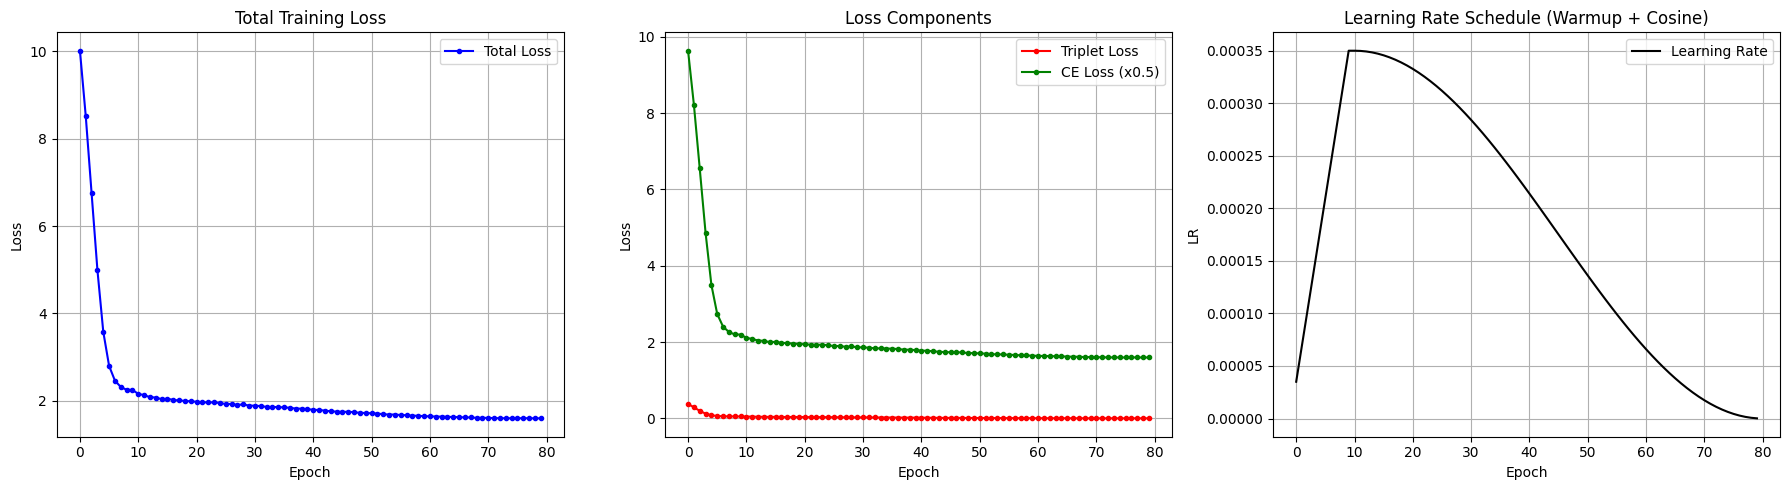

In [8]:
# === Training curves ===
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(epoch_losses, 'b-o', markersize=3, label='Total Loss')
axes[0].set_title('Total Training Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(triplet_losses, 'r-o', markersize=3, label='Triplet Loss')
axes[1].plot([c * CE_WEIGHT for c in ce_losses], 'g-o', markersize=3, label=f'CE Loss (x{CE_WEIGHT})')
axes[1].set_title('Loss Components')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True)

axes[2].plot(lr_history, 'k-', label='Learning Rate')
axes[2].set_title('Learning Rate Schedule (Warmup + Cosine)')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('LR')
axes[2].legend()
axes[2].grid(True)

plt.tight_layout()
plt.show()

## 8. Single Query — Top-5 Match Visualization

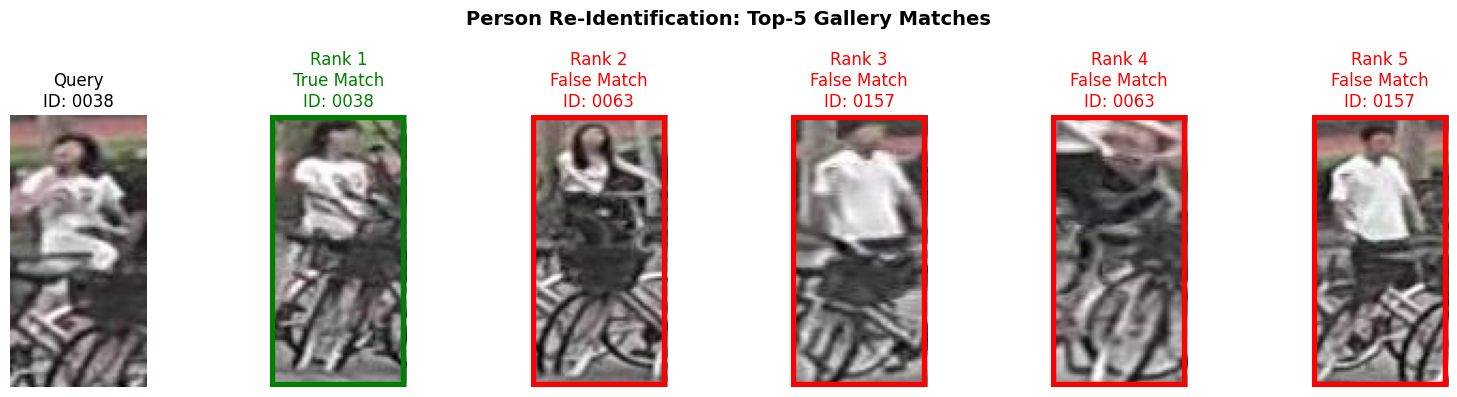

In [9]:
# === Top-5 ReID Match Visualization ===
sample_idx = 101

q_fname = query_files[sample_idx]
q_id_s  = q_ids[sample_idx]
q_cam_s = q_cams[sample_idx]
q_path  = os.path.join(query_dir, q_fname)

dists_s  = cdist(q_emb[sample_idx:sample_idx+1], g_emb, 'euclidean').flatten()
ranked_s = np.argsort(dists_s)

top5 = []
for j in ranked_s:
    gid, gcam = g_ids[j], g_cams[j]
    if gid in ('-1', '0000'):
        continue
    if gid == q_id_s and gcam == q_cam_s:
        continue
    top5.append((j, gid))
    if len(top5) == 5:
        break

fig, axes = plt.subplots(1, 6, figsize=(16, 4))

q_img = Image.open(q_path)
axes[0].imshow(q_img)
axes[0].set_title(f'Query\nID: {q_id_s}')
axes[0].axis('off')

for k, (idx, gid) in enumerate(top5):
    g_path = os.path.join(gallery_dir, gallery_files[idx])
    g_img  = Image.open(g_path)
    ax = axes[k + 1]
    ax.imshow(g_img)
    correct = (gid == q_id_s)
    color = 'green' if correct else 'red'
    label = 'True Match' if correct else 'False Match'
    ax.set_title(f'Rank {k+1}\n{label}\nID: {gid}', color=color)
    ax.axis('off')
    rect = patches.Rectangle((0, 0), g_img.width-1, g_img.height-1,
                             linewidth=6, edgecolor=color, facecolor='none')
    ax.add_patch(rect)

plt.suptitle('Person Re-Identification: Top-5 Gallery Matches', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 9. Performance Summary & Comparison

In [10]:
print('=' * 55)
print('  PERFORMANCE COMPARISON: Baseline vs Improved')
print('=' * 55)
print(f'  {"Metric":<12} {"Baseline":>12} {"Improved":>12} {"Delta":>10}')
print(f'  {"-"*12} {"-"*12} {"-"*12} {"-"*10}')

baseline_r1  = 54.42
baseline_r5  = 76.28
improved_r1  = cmc[0] * 100
improved_r5  = cmc[4] * 100
improved_r10 = cmc[9] * 100
improved_map = mAP * 100

print(f'  {"Rank-1":<12} {baseline_r1:>11.2f}% {improved_r1:>11.2f}% {improved_r1-baseline_r1:>+9.2f}%')
print(f'  {"Rank-5":<12} {baseline_r5:>11.2f}% {improved_r5:>11.2f}% {improved_r5-baseline_r5:>+9.2f}%')
print(f'  {"Rank-10":<12} {"N/A":>12} {improved_r10:>11.2f}%')
print(f'  {"mAP":<12} {"N/A":>12} {improved_map:>11.2f}%')
print('=' * 55)
print()
print('  Improvements Applied:')
print(f'  [+] Data Augmentation (Flip, Crop, ColorJitter, RandomErasing)')
print(f'  [+] BN Neck (separates triplet & classification)')
print(f'  [+] Label Smoothing (eps={LABEL_SMOOTH})')
print(f'  [+] Warmup ({WARMUP_EPOCHS} ep) + Cosine Annealing LR')
print(f'  [+] Embedding Dim: 128 -> {EMBEDDING_DIM}')
print(f'  [+] Triplet Margin: 1.0 -> {TRIPLET_MARGIN}')
print(f'  [+] CE Loss Weight: {CE_WEIGHT}')
print(f'  [+] Added mAP evaluation metric')

  PERFORMANCE COMPARISON: Baseline vs Improved
  Metric           Baseline     Improved      Delta
  ------------ ------------ ------------ ----------
  Rank-1             54.42%       89.22%    +34.80%
  Rank-5             76.28%       96.05%    +19.77%
  Rank-10               N/A       97.45%
  mAP                   N/A       73.93%

  Improvements Applied:
  [+] Data Augmentation (Flip, Crop, ColorJitter, RandomErasing)
  [+] BN Neck (separates triplet & classification)
  [+] Label Smoothing (eps=0.1)
  [+] Warmup (10 ep) + Cosine Annealing LR
  [+] Embedding Dim: 128 -> 256
  [+] Triplet Margin: 1.0 -> 0.3
  [+] CE Loss Weight: 0.5
  [+] Added mAP evaluation metric


---
# Presentation-Ready Visualizations

The following charts are designed for direct use in slides and reports.


## 10. Data Augmentation Examples
Shows original training images alongside 5 random augmented versions to illustrate the augmentation pipeline.


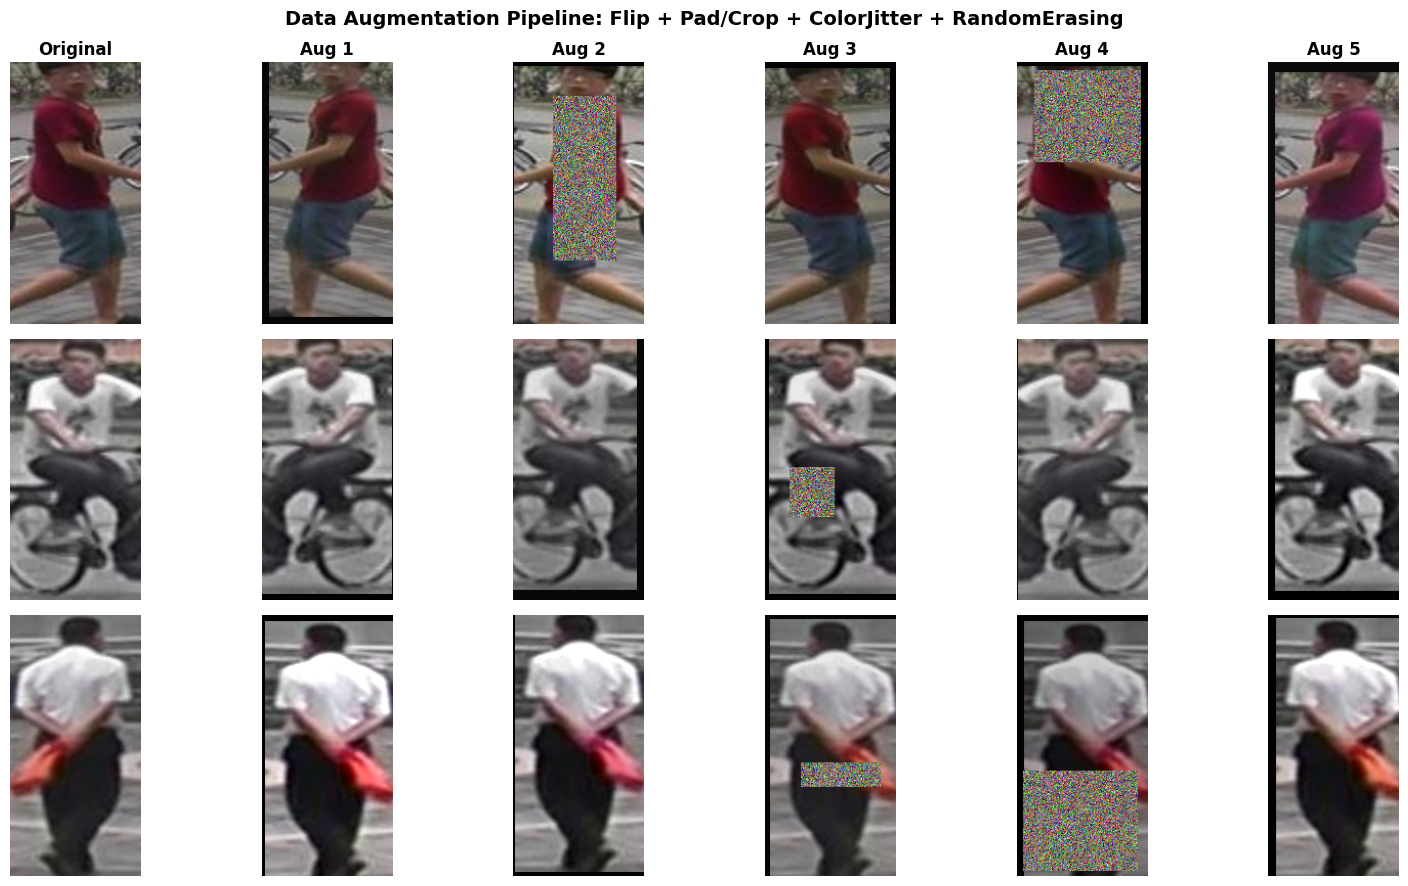

In [11]:
# === Augmentation Examples ===
sample_train_files = sorted([f for f in os.listdir(train_dir) if f.endswith('.jpg')])
# Pick 3 images from different identities
aug_samples = [sample_train_files[0], sample_train_files[100], sample_train_files[300]]

fig, axes = plt.subplots(3, 6, figsize=(16, 9))

col_titles = ['Original', 'Aug 1', 'Aug 2', 'Aug 3', 'Aug 4', 'Aug 5']
for col, title in enumerate(col_titles):
    axes[0, col].set_title(title, fontsize=12, fontweight='bold')

for row, fname in enumerate(aug_samples):
    img = Image.open(os.path.join(train_dir, fname)).convert('RGB')

    # Original (with eval transform for consistent display)
    orig_t = eval_transform(img)
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std  = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    orig_display = (orig_t * std + mean).clamp(0, 1).permute(1, 2, 0).numpy()
    axes[row, 0].imshow(orig_display)
    axes[row, 0].axis('off')
    pid = fname.split('_')[0]
    axes[row, 0].set_ylabel(f'ID: {pid}', fontsize=11, fontweight='bold', rotation=0, labelpad=50)

    # 5 augmented versions
    for col in range(1, 6):
        aug_t = train_transform(img)
        aug_display = (aug_t * std + mean).clamp(0, 1).permute(1, 2, 0).numpy()
        axes[row, col].imshow(aug_display)
        axes[row, col].axis('off')

plt.suptitle('Data Augmentation Pipeline: Flip + Pad/Crop + ColorJitter + RandomErasing',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 11. CMC Curve (Cumulative Matching Characteristic)
The standard evaluation chart for Person Re-Identification — shows the probability of finding a correct match within the top-k ranked results.


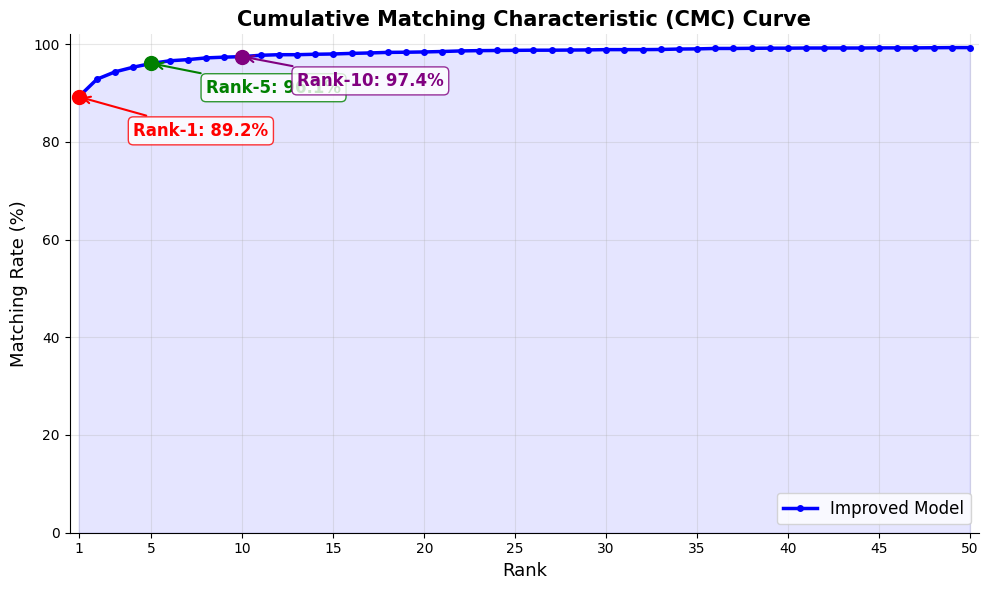

In [12]:
# === CMC Curve ===
fig, ax = plt.subplots(figsize=(10, 6))

max_rank = 50
ranks = np.arange(1, max_rank + 1)
cmc_values = cmc[:max_rank] * 100

ax.plot(ranks, cmc_values, 'b-o', markersize=4, linewidth=2.5, label='Improved Model')
ax.fill_between(ranks, 0, cmc_values, alpha=0.1, color='blue')

# Annotate key ranks
key_ranks = [(1, 'red'), (5, 'green'), (10, 'purple')]
for rank, color in key_ranks:
    val = cmc[rank - 1] * 100
    ax.plot(rank, val, 'o', color=color, markersize=10, zorder=5)
    offset_y = -8 if rank == 1 else -6
    offset_x = 3
    ax.annotate(f'Rank-{rank}: {val:.1f}%',
                xy=(rank, val), xytext=(rank + offset_x, val + offset_y),
                fontsize=12, fontweight='bold', color=color,
                arrowprops=dict(arrowstyle='->', color=color, lw=1.5),
                bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor=color, alpha=0.8))

ax.set_xlabel('Rank', fontsize=13)
ax.set_ylabel('Matching Rate (%)', fontsize=13)
ax.set_title('Cumulative Matching Characteristic (CMC) Curve', fontsize=15, fontweight='bold')
ax.set_xticks([1, 5, 10, 15, 20, 25, 30, 35, 40, 45, 50])
ax.set_ylim([0, 102])
ax.set_xlim([0.5, max_rank + 0.5])
ax.legend(fontsize=12, loc='lower right')
ax.grid(True, alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

## 12. t-SNE Embedding Visualization
Visualizes how well the model clusters embeddings of the same person together in 2D space. Well-separated clusters indicate strong discriminative embeddings.


Selected IDs: ['0260', '0001', '0228', '0227', '0094', '0183', '0727', '0155', '0270', '0092']
Image counts: [71, 59, 59, 58, 56, 55, 54, 53, 53, 50]
Total samples for t-SNE: 568
Running t-SNE (this may take ~30 seconds)...


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


Done!


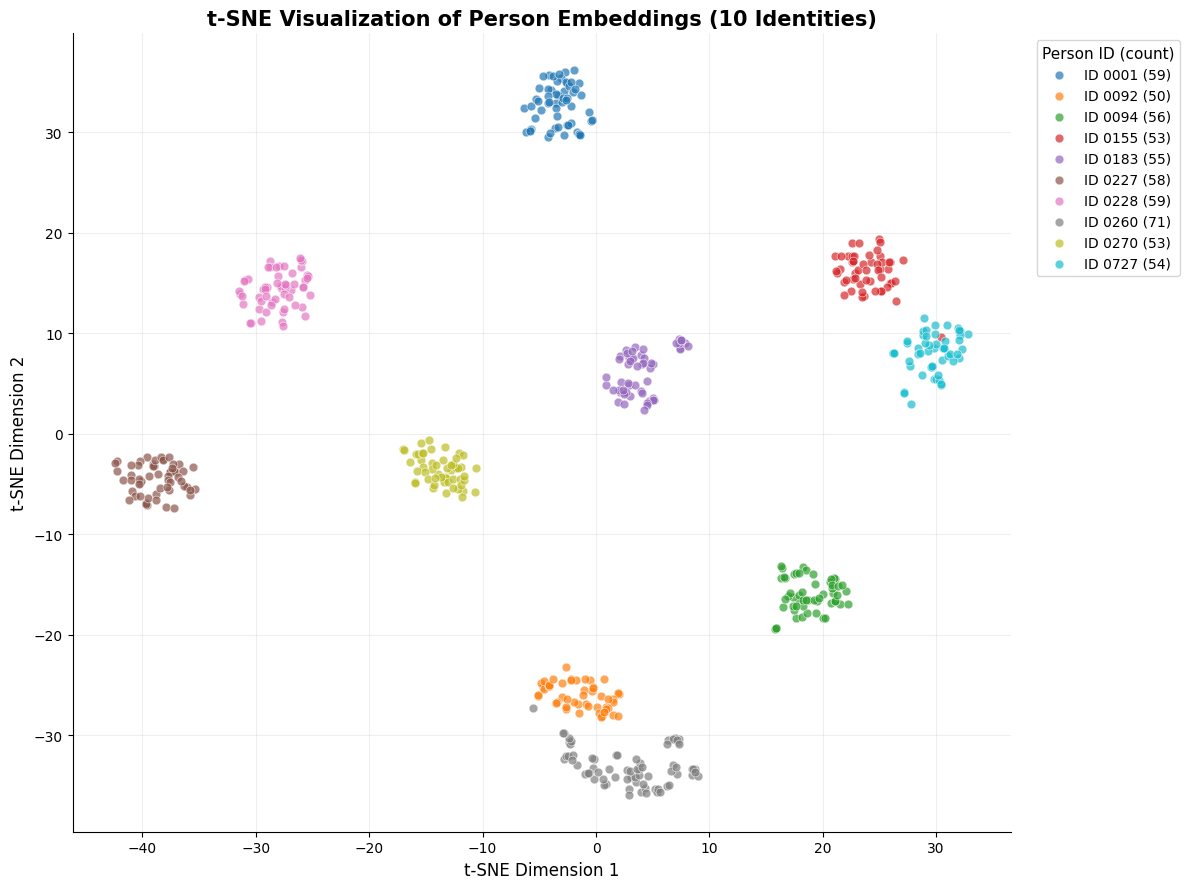

In [13]:
# === t-SNE Embedding Visualization ===
from sklearn.manifold import TSNE

# Select 10 identities with the most gallery images for clear visualization
id_counts = defaultdict(int)
for gid in g_ids:
    if gid not in ('-1', '0000'):
        id_counts[gid] += 1

top_10_ids = sorted(id_counts, key=id_counts.get, reverse=True)[:10]
print(f'Selected IDs: {top_10_ids}')
print(f'Image counts: {[id_counts[i] for i in top_10_ids]}')

# Gather embeddings for selected IDs
sel_emb, sel_ids = [], []
for i, gid in enumerate(g_ids):
    if gid in top_10_ids:
        sel_emb.append(g_emb[i])
        sel_ids.append(gid)

sel_emb = np.array(sel_emb)
sel_ids = np.array(sel_ids)
print(f'Total samples for t-SNE: {len(sel_emb)}')

# Run t-SNE
print('Running t-SNE (this may take ~30 seconds)...')
tsne = TSNE(n_components=2, random_state=42, perplexity=30, n_iter=1000)
emb_2d = tsne.fit_transform(sel_emb)
print('Done!')

# Plot
fig, ax = plt.subplots(figsize=(12, 9))
unique_ids = sorted(set(sel_ids))
colors = plt.cm.tab10(np.linspace(0, 1, len(unique_ids)))

for uid, color in zip(unique_ids, colors):
    mask = sel_ids == uid
    ax.scatter(emb_2d[mask, 0], emb_2d[mask, 1],
               c=[color], label=f'ID {uid} ({mask.sum()})',
               s=40, alpha=0.7, edgecolors='white', linewidth=0.5)

ax.set_title('t-SNE Visualization of Person Embeddings (10 Identities)',
             fontsize=15, fontweight='bold')
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=10,
          title='Person ID (count)', title_fontsize=11)
ax.set_xlabel('t-SNE Dimension 1', fontsize=12)
ax.set_ylabel('t-SNE Dimension 2', fontsize=12)
ax.grid(True, alpha=0.2)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

## 13. Multi-Query Retrieval Grid (5 Queries x Top-5 Matches)
Shows the model's retrieval performance across multiple diverse queries. Green borders = correct match, Red borders = incorrect match.


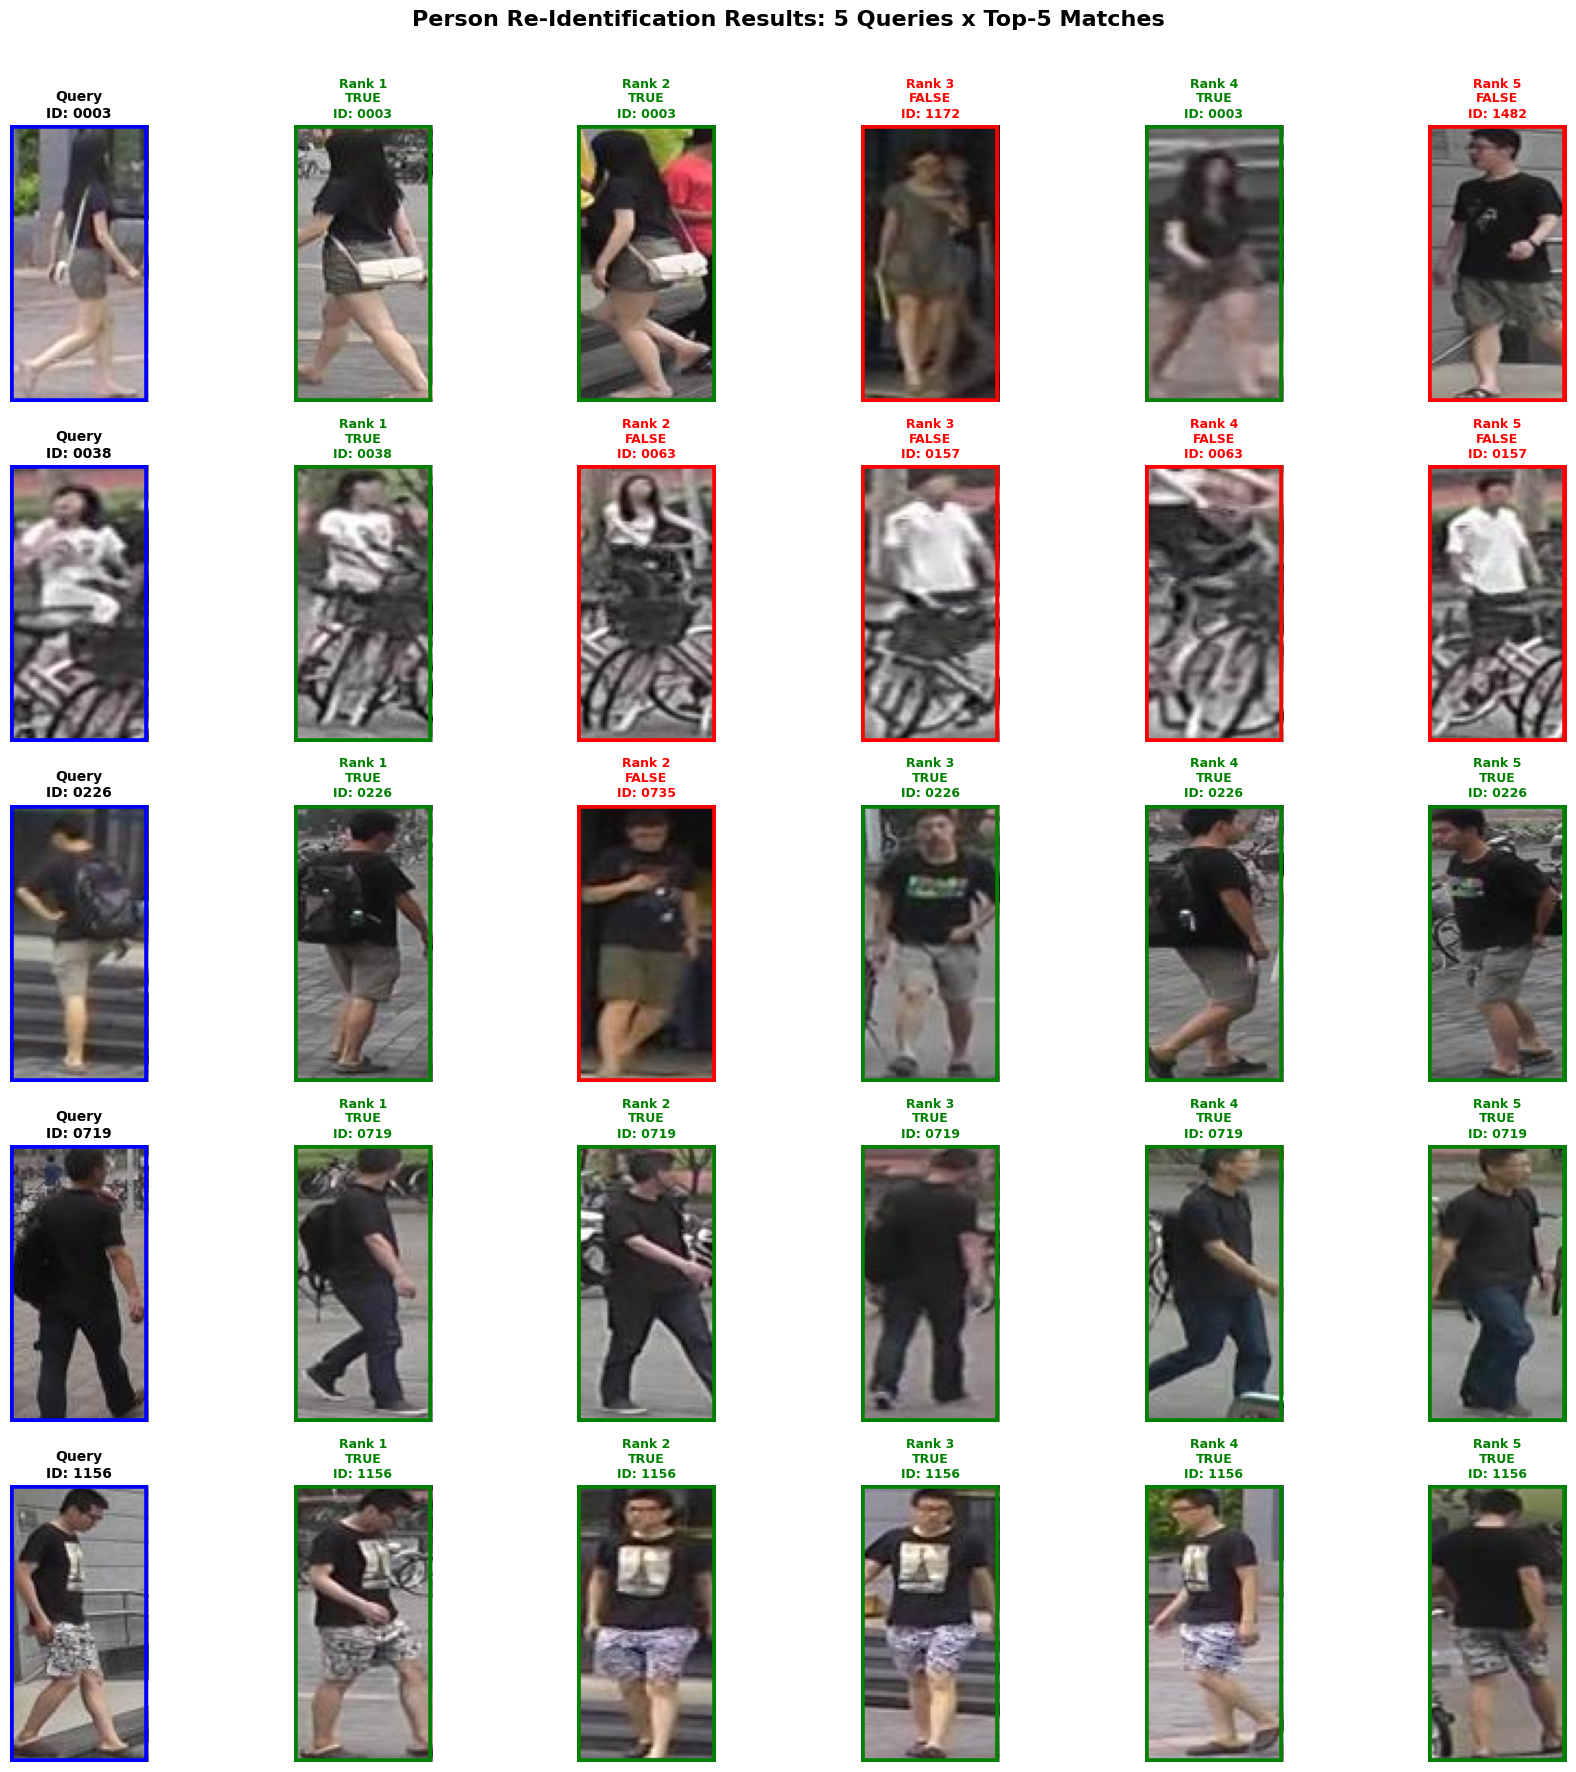

In [14]:
# === Multiple Query Visualization (5 queries x top-5 matches) ===
query_indices = [10, 101, 500, 1500, 2500]

n_queries = len(query_indices)
fig, axes = plt.subplots(n_queries, 6, figsize=(18, 3.5 * n_queries))

for row, qi in enumerate(query_indices):
    qf = query_files[qi]
    qid = q_ids[qi]
    qcam = q_cams[qi]
    qpath = os.path.join(query_dir, qf)

    # Query image with blue border
    qimg = Image.open(qpath)
    axes[row, 0].imshow(qimg)
    axes[row, 0].set_title(f'Query\nID: {qid}', fontsize=10, fontweight='bold')
    axes[row, 0].axis('off')
    rect = patches.Rectangle((0, 0), qimg.width - 1, qimg.height - 1,
                             linewidth=4, edgecolor='blue', facecolor='none')
    axes[row, 0].add_patch(rect)

    # Find top-5 matches
    d = cdist(q_emb[qi:qi+1], g_emb, 'euclidean').flatten()
    ranked = np.argsort(d)
    top = []
    for j in ranked:
        gid_j, gcam_j = g_ids[j], g_cams[j]
        if gid_j in ('-1', '0000'):
            continue
        if gid_j == qid and gcam_j == qcam:
            continue
        top.append((j, gid_j))
        if len(top) == 5:
            break

    for col, (gidx, gid_val) in enumerate(top):
        gpath = os.path.join(gallery_dir, gallery_files[gidx])
        gimg = Image.open(gpath)
        ax = axes[row, col + 1]
        ax.imshow(gimg)
        correct = (gid_val == qid)
        color = 'green' if correct else 'red'
        symbol = 'TRUE' if correct else 'FALSE'
        ax.set_title(f'Rank {col+1}\n{symbol}\nID: {gid_val}',
                     fontsize=9, color=color, fontweight='bold')
        ax.axis('off')
        rect = patches.Rectangle((0, 0), gimg.width - 1, gimg.height - 1,
                                 linewidth=4, edgecolor=color, facecolor='none')
        ax.add_patch(rect)

plt.suptitle('Person Re-Identification Results: 5 Queries x Top-5 Matches',
             fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## 14. Bar Chart — Baseline vs Improved Comparison
Side-by-side comparison of the baseline model (no augmentation, no BN Neck) versus the improved model.


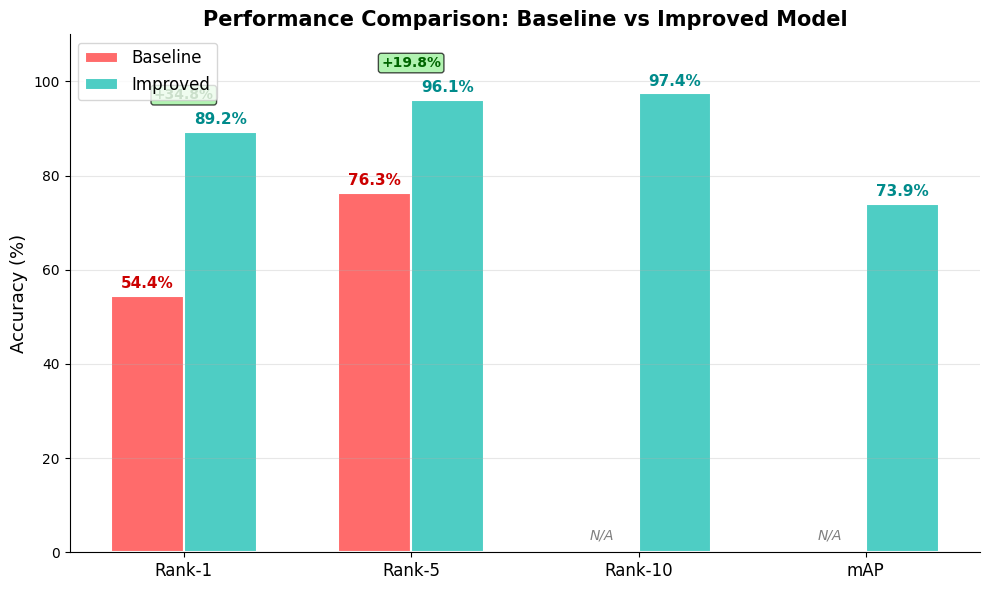

In [15]:
# === Bar Chart: Baseline vs Improved ===
fig, ax = plt.subplots(figsize=(10, 6))

metrics = ['Rank-1', 'Rank-5', 'Rank-10', 'mAP']
baseline_vals = [54.42, 76.28, None, None]  # Rank-10 and mAP not available for baseline
improved_vals = [cmc[0]*100, cmc[4]*100, cmc[9]*100, mAP*100]

x = np.arange(len(metrics))
width = 0.32

# Baseline bars (only for Rank-1 and Rank-5)
base_colors = ['#FF6B6B', '#FF6B6B', '#DDDDDD', '#DDDDDD']
base_vals_plot = [v if v is not None else 0 for v in baseline_vals]
bars1 = ax.bar(x - width/2, base_vals_plot, width, label='Baseline',
               color=base_colors, edgecolor='white', linewidth=1.5)

# Improved bars
bars2 = ax.bar(x + width/2, improved_vals, width, label='Improved',
               color='#4ECDC4', edgecolor='white', linewidth=1.5)

# Value labels
for i, bar in enumerate(bars1):
    if baseline_vals[i] is not None:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                f'{baseline_vals[i]:.1f}%', ha='center', va='bottom',
                fontweight='bold', fontsize=11, color='#CC0000')
    else:
        ax.text(bar.get_x() + bar.get_width()/2, 2,
                'N/A', ha='center', va='bottom',
                fontsize=10, color='gray', fontstyle='italic')

for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f'{bar.get_height():.1f}%', ha='center', va='bottom',
            fontweight='bold', fontsize=11, color='#008B8B')

# Delta annotations for Rank-1 and Rank-5
for i in range(2):
    delta = improved_vals[i] - baseline_vals[i]
    mid_x = x[i]
    mid_y = max(baseline_vals[i], improved_vals[i]) + 7
    ax.annotate(f'+{delta:.1f}%', xy=(mid_x, mid_y), fontsize=10,
                fontweight='bold', color='#006400', ha='center',
                bbox=dict(boxstyle='round,pad=0.2', facecolor='#90EE90', alpha=0.7))

ax.set_ylabel('Accuracy (%)', fontsize=13)
ax.set_title('Performance Comparison: Baseline vs Improved Model',
             fontsize=15, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(metrics, fontsize=12)
ax.set_ylim(0, 110)
ax.legend(fontsize=12, loc='upper left')
ax.grid(axis='y', alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()